# Current Manufacturing Workforce Stability Plan

## Executive summary

The final notebook applies the frozen, out-of-time-tested policy to the
current active synthetic workforce as of 2026-06-30. It translates calibrated
probabilities into probability-weighted departure, prevention, backfill, and
operational planning scenarios.

Current outcomes are unknown. These values are expectations under explicit
assumptions, not another model-performance test or guaranteed forecasts.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "config" / "portfolio_notebooks.yaml").exists():
            return candidate
    raise FileNotFoundError("Run this notebook inside the project repository.")


PROJECT_ROOT = find_project_root()
PROCESSED = PROJECT_ROOT / "data" / "processed"

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

## Current planning population

Protected hierarchy levels remain in workforce headcount but outside the
retention intervention model. The frozen policy reviews at most 700 eligible
employees.

In [2]:
metadata = pd.read_csv(
    PROCESSED / "dashboard" / "dashboard_metadata.csv"
)
current_plan = pd.read_csv(
    PROCESSED / "current_retention_policy_summary.csv"
)

display(
    metadata[
        [
            "as_of_date",
            "workforce_status_label",
            "model_status_label",
            "final_test_snapshot",
            "selected_policy",
        ]
    ].T
)
display(current_plan.T)

,0
as_of_date,2026-06-30
workforce_status_label,Current active synthetic workforce
model_status_label,Out-of-time tested planning projection
final_test_snapshot,2025-06-30
selected_policy,Budget-constrained expected value


,0
snapshot_date,2026-06-30
eligible_employees,7305
selected_for_human_review,700
intervention_budget_usd,1750000.0
projected_intervention_spend_usd,1750000.0
projected_expected_prevented_departures,35.034285
projected_expected_avoided_cost_usd,4146215.597823
projected_expected_net_value_usd,2396215.597823
human_review_required,True
automatic_employment_action_permitted,False


The current model is refitted on all observed historical snapshots after the
final test. This improves current estimation, but outcomes after 2026-06-30
are unavailable and cannot be used to claim new performance.

## Department stability outlook

Expected departures equal the sum of current twelve-month probabilities.
Expected prevented departures additionally apply the 25% intervention-success
assumption to selected employees.

In [3]:
departments = pd.read_csv(
    PROCESSED / "workforce_stability_by_department.csv"
)
department_table = departments[
    [
        "department_name",
        "active_workforce_employees",
        "expected_departures_12m",
        "selected_for_human_review",
        "expected_prevented_departures",
        "residual_expected_backfills",
        "planned_net_value_usd",
    ]
].sort_values("expected_departures_12m", ascending=False)
display(department_table.round(1))

,department_name,active_workforce_employees,expected_departures_12m,selected_for_human_review,expected_prevented_departures,residual_expected_backfills,planned_net_value_usd
0,Manufacturing,1832,229.7,162,8.4,221.3,492919.4
1,Engineering,1532,165.5,251,10.6,154.8,982912.6
2,Supply Chain,916,98.4,31,1.7,96.7,88558.9
3,Information Technology,745,93.7,152,7.5,86.3,524741.4
4,Customer Support,544,84.8,8,0.7,84.0,19450.9
5,Sales,750,84.6,18,1.0,83.6,52168.6
6,Finance,579,80.7,55,3.6,77.1,167943.2
7,Human Resources,511,66.6,23,1.6,65.0,67520.5


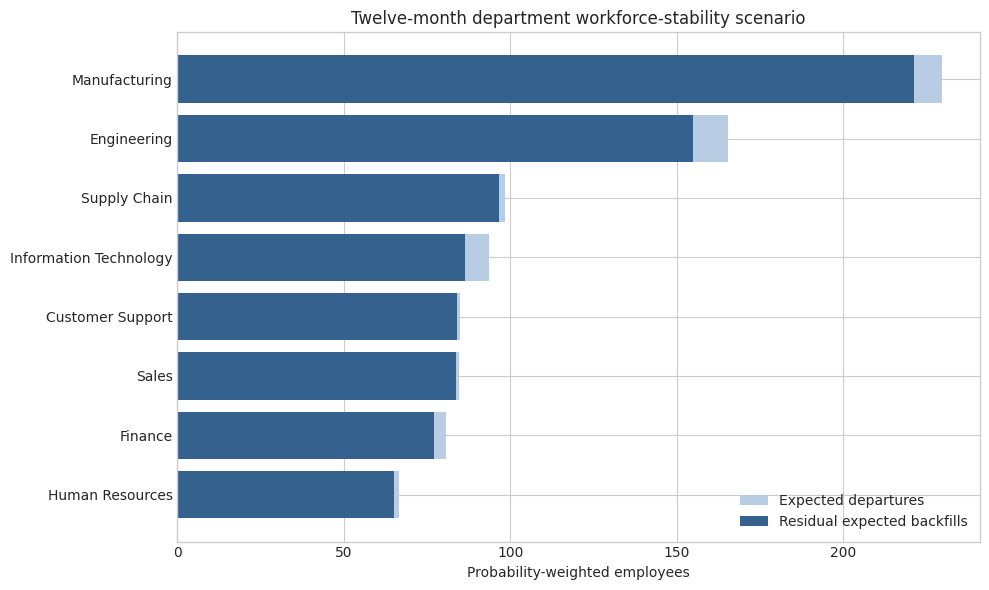

In [4]:
plot_departments = departments.sort_values(
    "expected_departures_12m"
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_departments["department_name"],
    plot_departments["expected_departures_12m"],
    label="Expected departures",
    color="#b8cde3",
)
plt.barh(
    plot_departments["department_name"],
    plot_departments["residual_expected_backfills"],
    label="Residual expected backfills",
    color="#35618f",
)
plt.xlabel("Probability-weighted employees")
plt.title("Twelve-month department workforce-stability scenario")
plt.legend()
plt.tight_layout()
plt.show()

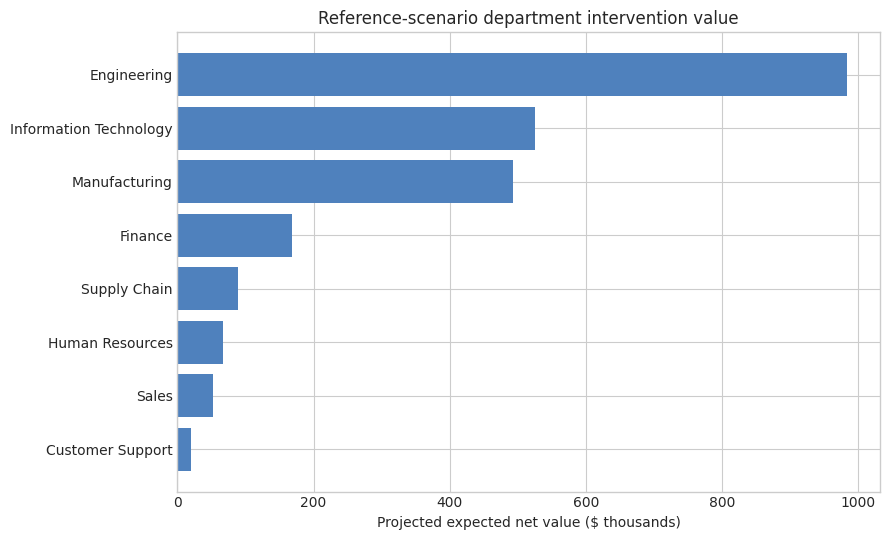

In [5]:
net_value = departments.sort_values("planned_net_value_usd")

plt.figure(figsize=(9, 5.5))
plt.barh(
    net_value["department_name"],
    net_value["planned_net_value_usd"] / 1_000,
    color="#4f81bd",
)
plt.xlabel("Projected expected net value ($ thousands)")
plt.title("Reference-scenario department intervention value")
plt.tight_layout()
plt.show()

Manufacturing has the largest probability-weighted departure and backfill
exposure. Engineering receives more reviews under the expected-value policy
because the policy also considers avoidable replacement cost.

## Manufacturing role plan

Manufacturing is the focus because workforce continuity and backfill demand
are directly connected to production operations.

In [6]:
manufacturing = pd.read_csv(
    PROCESSED / "manufacturing_stability_summary.csv"
)
summary_fields = [
    "as_of_date",
    "active_workforce_employees",
    "model_eligible_employees",
    "expected_departures_12m",
    "selected_for_human_review",
    "expected_prevented_departures",
    "residual_expected_backfills",
    "planned_intervention_spend_usd",
    "planned_net_value_usd",
]
display(manufacturing[summary_fields].T.round(2))

,0
as_of_date,2026-06-30
active_workforce_employees,1832
model_eligible_employees,1808
expected_departures_12m,229.652193
selected_for_human_review,162
expected_prevented_departures,8.371237
residual_expected_backfills,221.280956
planned_intervention_spend_usd,405000.0
planned_net_value_usd,492919.399697


In [7]:
roles = pd.read_csv(
    PROCESSED / "manufacturing_backfill_by_role.csv"
)
role_table = roles[
    [
        "job_title",
        "active_workforce_employees",
        "expected_departures_12m",
        "selected_for_human_review",
        "expected_prevented_departures",
        "residual_expected_backfills",
        "residual_training_hours",
        "residual_coverage_hours",
    ]
]
display(role_table.round(1))

,job_title,active_workforce_employees,expected_departures_12m,selected_for_human_review,expected_prevented_departures,residual_expected_backfills,residual_training_hours,residual_coverage_hours
0,Production Technician,783,107.7,4,0.4,107.3,8582.8,19311.3
1,Manufacturing Engineer,839,97.1,113,5.7,91.4,7312.5,16453.1
2,Production Supervisor,210,24.9,45,2.3,22.6,1807.2,4066.1


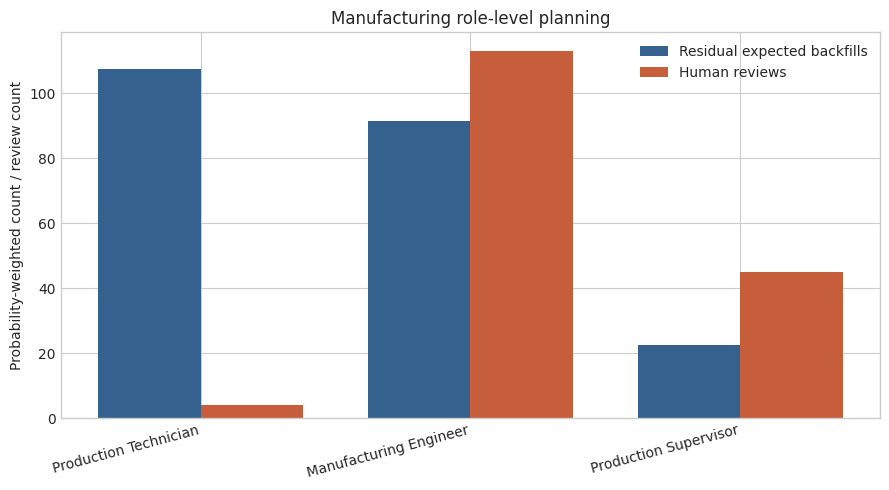

In [8]:
figure, axis = plt.subplots(figsize=(9, 5))
positions = range(len(roles))
width = 0.38

axis.bar(
    [position - width / 2 for position in positions],
    roles["residual_expected_backfills"],
    width=width,
    label="Residual expected backfills",
    color="#35618f",
)
axis.bar(
    [position + width / 2 for position in positions],
    roles["selected_for_human_review"],
    width=width,
    label="Human reviews",
    color="#c65d3b",
)
axis.set_xticks(list(positions))
axis.set_xticklabels(roles["job_title"], rotation=15, ha="right")
axis.set_ylabel("Probability-weighted count / review count")
axis.set_title("Manufacturing role-level planning")
axis.legend()
figure.tight_layout()
plt.show()

The Production Technician role drives the largest residual backfill and
training exposure, even though relatively few technicians enter the
expected-value review set. That contrast is a planning insight, not evidence
that technicians deserve less organizational support.

## Decision boundaries and limitations

The current planning layer must preserve the tested policy and clearly separate
expected values from observed outcomes.

In [9]:
stability_checks = pd.read_csv(
    PROCESSED / "workforce_stability_validation.csv"
)
display(
    pd.DataFrame(
        {
            "validation_checks": [len(stability_checks)],
            "passed": [stability_checks["status"].eq("PASS").sum()],
            "failed": [stability_checks["status"].ne("PASS").sum()],
            "human_review_required": [
                bool(manufacturing["human_review_required"].iloc[0])
            ],
            "automatic_action_permitted": [
                bool(manufacturing["automatic_action_permitted"].iloc[0])
            ],
        }
    )
)

,validation_checks,passed,failed,human_review_required,automatic_action_permitted
0,20,20,0,True,False


Key limitations:

- Expected departure counts are sums of probabilities, not exact headcount
  forecasts.
- Intervention effectiveness is assumed rather than causally estimated.
- Replacement costs and operational units are scenarios.
- Current scores have no known future labels.
- Human review is mandatory; automatic employment action is prohibited.
- All people, histories, and outcomes are synthetic.

### Portfolio navigation

Previous: [Fairness, Economics, and Retention Policy](03_fairness_economics_and_policy.ipynb)  
Return to the [Notebook Portfolio Guide](../README.md).